# Assignment 2
## ✅ Rename the filename with your roll number. E.g. if your roll number is `MT24003` then rename the file `MT24003_a2.ipynb`.
## ✅ Write code only in the sections marked with `# YOUR CODE HERE`. No, you can NOT write code anywhere else.
## ✅ Download and extract the `data.zip` folder next to this file. If you extract it correctly, you will have a `data` folder next to this file.
## ✅ Submit a .zip (NOT .tar, .rar, etc) file containining:
###    1. This Notebook after filling the code where asked.
###    2. The loss and metric plots generated using the `save_training_report` functions [`auto_encoder.png` + `variational_auto_encoder.png` + `conditional_variational_auto_encoder.png`].
###    3. The model weights saved using the  `save_model_weights` functions [`auto_encoder.pth` + `variational_auto_encoder.pth` + `conditional_variational_auto_encoder.pth`].
## ❌ Do not modify any other function or class definitions; doing so may lead to the autograder failing to judge your submission, resulting in a zero.
## ❌ Deleting or adding new cells may lead to the `autograder` failing to judge your submission, resulting in a zero. Even if a cell is empty, do NOT delete it.
## ❌ Do NOT install / import any other libraries. You should be able to solve all the questions using only the libraries imported below.

In [ ]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 -q
!pip install numpy==1.25.2 -q
!pip install soundfile==0.13.0 -q
!pip install pandas==2.2.3 -q
!pip install matplotlib==3.9.4 -q
!pip install scikit-image==0.21.0 -q
!pip install tqdm==4.67.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.

In [2]:
import os
import random
import timeit
from pathlib import Path
from typing import Tuple
from skimage.metrics import structural_similarity as ssim
from numpy import array as NumpyArray
from typing import List

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torchvision
from tqdm import tqdm

In [3]:
PATH_TO_DATA_DIR = Path("./data")
PATH_TO_TRAIN_DATA_DIR = str(PATH_TO_DATA_DIR / "train")
PATH_TO_TEST_DATA_DIR = str(PATH_TO_DATA_DIR / "test")

# `q1`: `FashionMNIST` Dataset
1. Implement a Dataset class for the `FashionMNIST` data for the task of `Image Restoration`.
2. The task of `Image Restoration` is an [Ill-posed problem](https://en.wikipedia.org/wiki/Well-posed_problem) where the goal is to restore the original image from a corrupted image. Thus there may be more than one augmented image for each clean image, and vice versa.
3. The `data` directory has the following directory structure:
4. ```
	data
    ├── train
    │   ├── aug
    │   │   ├── <imagenumber>_<classlabel>.png
    │   │   ├── ...
    │   ├── clean
    │   │   ├── <imagenumber>_<classlabel>.png
    │   │   ├── ...
    └── test
        ├── aug
        │   ├── <imagenumber>_<classlabel>.png
        │   ├── ...
        └── clean
            ├── <imagenumber>_<classlabel>.png
            ├── ...
    ```
5. Constraints:
   1. The `__getitem__` method should return a tuple of the form `(aug_image, clean_image, label)`.  `clean_image` is the clean image, `aug_image` is the augmented image, and `label` is the class label of the image.
   2. Both `clean_image` and `aug_image` tensors should be of the shape `(1, 28, 28)` and of type `torch.float32`.
   3. Both `clean_image` and `aug_image` tensors should have pixel values between `[0, 1]`.
   4. `label` should be of type `torch.int64`.


`q1` Grading [Total: 1]: `1` point if the code runs without any errors on hidden test cases, otherwise `0` points. No partial points for this question.

In [4]:
class FashionMNISTDataset(torch.utils.data.Dataset):
    """
    A PyTorch Dataset for loading paired FashionMNIST images (augmented and clean versions).

    Attributes:
        augmented_images (List[str]): List of file paths to augmented images, sorted alphabetically.
        clean_images (List[str]): List of file paths to clean images, sorted alphabetically.
    """
    def __init__(
        self, path_to_augmented_images_dir: str, path_to_clean_images_dir: str
    ):
        """
        Initializes the dataset by loading file paths for augmented and clean images.

        Args:
            path_to_augmented_images_dir (str): Path to the directory containing augmented images.
            path_to_clean_images_dir (str): Path to the directory containing clean images.
        """
        # YOUR CODE HERE
        # raise NotImplementedError()
        self.augmented_images = sorted(
            [os.path.join(path_to_augmented_images_dir, f) for f in os.listdir(path_to_augmented_images_dir)]
        )
        self.clean_images = sorted(
            [os.path.join(path_to_clean_images_dir, f) for f in os.listdir(path_to_clean_images_dir)]
        )

        self.transform = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor()
        ])

    def __len__(self) -> int:
        """
        Returns the total number of samples in the dataset.

        Returns:
            int
        """
        # YOUR CODE HERE
        # raise NotImplementedError()
        return min(len(self.augmented_images), len(self.clean_images))

    def __getitem__(self, idx) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Retrieves the augmented image, clean image, and label for a given index.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
                - Augmented image as a tensor with values normalized to [0, 1].
                - Clean image as a tensor with values normalized to [0, 1].
                - Label as an integer tensor, extracted from the filename.
        """
        # YOUR CODE HERE
        # raise NotImplementedError()

        aug_img_path = self.augmented_images[idx]
        clean_img_path = self.clean_images[idx]

        aug_img = torchvision.io.read_image(aug_img_path) / 255.0
        clean_img = torchvision.io.read_image(clean_img_path) / 255.0

        def register_image(aug_img_tensor, clean_img_tensor):
            best_ssim = -1
            best_transformed = aug_img

            flips = [(False, False), (True, False), (False, True), (True, True)]

            for angle in range(-180, 181, 15):
                for shear in range(-2, 3, 2):
                    for flip_h, flip_v in flips:
                        transformed_img = aug_img_tensor.clone()

                        if transformed_img.ndim == 2:
                            transformed_img = transformed_img.unsqueeze(0)

                        if flip_h:
                            transformed_img = torch.flip(transformed_img, dims=[2])

                        if flip_v:
                            transformed_img = torch.flip(transformed_img, dims=[1])

                        transformed_img = torchvision.transforms.functional.rotate(transformed_img, angle)

                        transformed_img = torchvision.transforms.functional.affine(
                            transformed_img, angle=0, translate=[0, 0], scale=1.0, shear=[(shear / 10) * 180, 0]
                        )

                        ssim_score = ssim(
                            transformed_img.squeeze(0).cpu().numpy(), clean_img_tensor.squeeze(0).cpu().numpy(), data_range=1
                        )

                        if ssim_score > best_ssim:
                            best_ssim = ssim_score
                            best_transformed = transformed_img.clone()

            return best_transformed

        # aug_img = register_image(aug_img, clean_img)

        # aug_img = aug_img.contiguous()
        # aug_img = aug_img.permute(0, 1, 2)

        label = int(self.clean_images[idx].split("_")[-1].split(".")[0])

        return aug_img.float(), clean_img.float(), torch.tensor(label, dtype=torch.int64)

In [ ]:
# tests for q1

path_to_train_images_aug_dir = str(PATH_TO_TRAIN_DATA_DIR + "/aug")
path_to_train_images_clean_dir = str(PATH_TO_TRAIN_DATA_DIR + "/clean")
fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_train_images_aug_dir,
    path_to_clean_images_dir=path_to_train_images_clean_dir,
)


In [ ]:
# tests for q1

path_to_test_images_aug_dir = str(PATH_TO_TEST_DATA_DIR + "/aug")
path_to_test_images_clean_dir = str(PATH_TO_TEST_DATA_DIR + "/clean")
fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_test_images_aug_dir,
    path_to_clean_images_dir=path_to_test_images_clean_dir,
)


del fashion_mnist_dataset

# `q2`: Encoder, and Decoder classes

* Your task is to create AutoEncoder models for the task of `Image Restoration` using the `FashionMNIST` dataset. You need to implement the `Encoder` and `Decoder` classes for the AutoEncoder model. The `Encoder` class will be used to encode the input image into a latent representation, and the `Decoder` class will be used to decode the latent representation back to the original image. The `Encoder` and `Decoder` classes will be used in the AutoEncoder model, Variational AutoEncoder model, and (optionally) Conditional AutoEncoder model, so the implementation should be **generic and not specific** to any of the models.
* `q2a`: `Encoder` class: Implement a generic Encoder Module that will be used within all the AutoEncoder flavors (AutoEncoder, Variational AutoEncoder, and (optinally) Conditional AutoEncoder). Constraints:
  1. The input tensor will be of shape `[batch_size, 1, 28, 28]` that comes out of the DataLoader of the `FashionMNIST` dataset.
  2. Feel free to use any architecture you like with any layer or activation function in it. **You can NOT use pre-trained model weights**.
  3. The output tensor must be of shape `[batch_size, output_channels, height, width]`. This tensor will be the latent representation of the input tensor and will be passed to the Decoder Module.
  4. The number of parameters in the Encoder Module must be between 2,000 and 1,000,000 (both inclusive). Note that the number of parameters in the Encoder Module and Decoder Module will be counted separately and may not be the same.

* `q2b`: `Decoder` class: Implement a generic Decoder Module that will be used within all the AutoEncoder flavors (AutoEncoder, Variational AutoEncoder, and (optinally) Conditional AutoEncoder). Constraints:
  1. The input tensor will be of shape `[batch_size, input_channels, height, width]` that comes out of the Encoder Module.
  2. Feel free to use any architecture you like with any layer or activation function in it. **You can NOT use pre-trained model weights**.
  3. The output tensor must be of shape `[batch_size, 1, 28, 28]`. This tensor will be the reconstructed image of the input tensor.
  4. The number of parameters in the Decoder Module must be between 2,000 and 1,000,000 (both inclusive). Note that the number of parameters in the Encoder Module and Decoder Module will be counted separately and may not be the same.

`q2` Grading [Total: 1 point]:
1. `q2a`: `Encoder` class: `0.5` points if the code runs without any errors on hidden test cases, otherwise 0 points. No partial points for this question.
2. `q2b`: `Decoder` class:  `0.5` points if the code runs without any errors on hidden test cases, otherwise 0 points. No partial points for this question.

## `q2a`: `Encoder` class

In [5]:
class Encoder(torch.nn.Module):
    def __init__(self, output_channels: int, type_of_autoencoder: str = None):
        super(Encoder, self).__init__()
        # YOUR CODE HERE
        # raise NotImplementedError()
        self.type_of_autoencoder = type_of_autoencoder
        self.output_channels = output_channels

        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.LeakyReLU(0.2),

            torch.nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.LeakyReLU(0.2),

            torch.nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.LeakyReLU(0.2),

            torch.nn.Conv2d(128, output_channels, kernel_size=3, stride=2, padding=1),
            torch.nn.BatchNorm2d(output_channels),
            torch.nn.LeakyReLU(0.2)
        )


    def forward(self, x):
        # YOUR CODE HERE
        # raise NotImplementedError()
        x = self.conv_layers(x)

        return x

In [ ]:
# tests for q2a

encoder = Encoder(output_channels=64, type_of_autoencoder="vae")

random_input_tensor = torch.randn(1, 1, 28, 28)
output_tensor = encoder(random_input_tensor)


del encoder

## `q2b`: `Decoder` class

In [7]:
class Decoder(torch.nn.Module):
    def __init__(self, input_channels: int, type_of_autoencoder: str):
        super(Decoder, self).__init__()
        # YOUR CODE HERE
        # raise NotImplementedError()
        self.type_of_autoencoder = type_of_autoencoder
        self.input_channels = input_channels

        self.deconv_layers = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(input_channels, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            # torch.nn.LeakyReLU(0.2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            # torch.nn.LeakyReLU(0.2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            # torch.nn.LeakyReLU(0.2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            torch.nn.Sigmoid()
        )


    def forward(self, x):
        # YOUR CODE HERE
        # raise NotImplementedError()
        x = self.deconv_layers(x)

        return x

In [ ]:
# tests for q2b

decoder = Decoder(input_channels=64, type_of_autoencoder="vae")

random_input_tensor = torch.randn(1, 64, 4, 4)
output_tensor = decoder(random_input_tensor)


del decoder

# `q3`: AutoEncoder Model
* `q3a`: `AutoEncoder` class: Implement a AutoEncoder that uses the Encoder and Decoder Modules implemented in `q2a` and `q2b`. Constraints:
  1. The number of parameters in the AutoEncoder must be between 4,000 and 2,000,000 (both inclusive).
  2. The input tensor will be of shape `[batch_size, 1, 28, 28]` that comes out of the DataLoader of the `FashionMNIST` dataset.
  3. The output tensor must be of shape `[batch_size, 1, 28, 28]`. This tensor will be the reconstructed image of the input tensor.

* `q3b`: Training the models: Implement the training loop for the AutoEncoder model. Constraints:
  1. Use the `FashionMNIST` dataset implemented in `q1` to load the data.
  2. Use the `AutoEncoder` model implemented in `q3a`.
  3. You are free to choose any loss function, optimizer, and hyperparameters.
  4. **You must**:
     1. Book-keep the training and validation losses and SSIM scores for each epoch and use it to plot the training curves with the `AutoEncoder.save_training_report` method.
     2. To calculate the SSIM score, you can use the `get_ssim` function provided below.
     3. Save the model weights using `AutoEncoder.save_model_weights` method.


`q3` Grading [Total: 1.5 points]:
1. `q3a`: `AutoEncoder` class: `0.5` points if the code runs without any errors on hidden test cases, otherwise 0 points. No partial points for this question.
2. `q3b`: Training the models: `1` points. You will be awarded points based on the SSIM score of the `AutoEncoder` model on a **hidden test set**. The grading will be as follows:
   1. 0.8 or more: `1` point
   2. 0.7 to 0.79: `0.8` points
   3. 0.6 to 0.69: `0.6` points
   4. 0.5 to 0.59: `0.4` points
   5. 0.4 to 0.49: `0.2` points
   6. Less than 0.4: `0` points


You are provided with the following template. **Populate only the sections marked as `# YOUR CODE HERE`. Do not modify other parts of the template.**

## `q3a`: `AutoEncoder` class

In [8]:
class AutoEncoder(torch.nn.Module):
    def __init__(self, latent_dim: int):
        super(AutoEncoder, self).__init__()
        self.encoder = Encoder(output_channels=latent_dim, type_of_autoencoder="ae")
        self.decoder = Decoder(input_channels=latent_dim, type_of_autoencoder="ae")
        self.latent_dim = latent_dim

    def forward(self, input_tensor):
        # YOUR CODE HERE
        # raise NotImplementedError()
        encoded = self.encoder(input_tensor)
        reconstructed = self.decoder(encoded)
        return reconstructed

    def save_model_weights(self):
        torch.save(self.state_dict(), "auto_encoder.pth")

    def load_model_weights(self):
        self.load_state_dict(torch.load("auto_encoder.pth"))

    def save_training_report(
        self,
        list_of_train_losses: List[float],
        list_of_val_losses: List[float],
        list_of_train_ssim_scores: List[float],
        list_of_val_ssim_scores: List[float],
    ):
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title("Loss per Epoch")
        plt.plot(list_of_train_losses, label="Training")
        plt.plot(list_of_val_losses, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.title("SSIM per Epoch")
        plt.plot(list_of_train_ssim_scores, label="Training")
        plt.plot(list_of_val_ssim_scores, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("SSIM")
        plt.legend()

        plt.suptitle("AutoEncoder Training Report")

        plt.savefig("auto_encoder.png")
        plt.show()

In [ ]:
# tests for q3a

autoencoder = AutoEncoder(latent_dim=64)

random_input_tensor = torch.randn(1, 1, 28, 28)
output_tensor = autoencoder(random_input_tensor)


del autoencoder

## `q3b`: Training the model

In [9]:
def get_ssim(
    list_of_predicted_images: List[NumpyArray], list_of_true_images: List[NumpyArray]
) -> List[float]:
    ssim_values = []
    for predicted_image, true_image in zip(
        list_of_predicted_images, list_of_true_images
    ):
        assert predicted_image.shape == (
            28,
            28,
        ), f"Expected image of shape (28, 28) but got {predicted_image.shape}"
        assert true_image.shape == (
            28,
            28,
        ), f"Expected image of shape (28, 28) but got {true_image.shape}"
        ssim_values.append(
            ssim(
                predicted_image,
                true_image,
                data_range=true_image.max() - true_image.min(),
            )
        )
    return sum(ssim_values) / len(ssim_values)

Epoch 1/70 [Validation]: 100%|██████████| 79/79 [00:03<00:00, 23.26it/s]


Epoch [1/70] Train Loss: 0.2572, Train SSIM: 0.4930 Val Loss: 0.2110, Val SSIM: 0.5589


Epoch 2/70 [Validation]: 100%|██████████| 79/79 [00:02<00:00, 28.27it/s]


Epoch [2/70] Train Loss: 0.1881, Train SSIM: 0.5842 Val Loss: 0.1960, Val SSIM: 0.5929


Epoch 3/70 [Validation]: 100%|██████████| 79/79 [00:03<00:00, 25.96it/s]


...

Epoch [69/70] Train Loss: 0.0977, Train SSIM: 0.7306 Val Loss: 0.1397, Val SSIM: 0.6812


Epoch 70/70 [Validation]: 100%|██████████| 79/79 [00:02<00:00, 29.00it/s]

Epoch [70/70] Train Loss: 0.0977, Train SSIM: 0.7307 Val Loss: 0.1400, Val SSIM: 0.6814


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

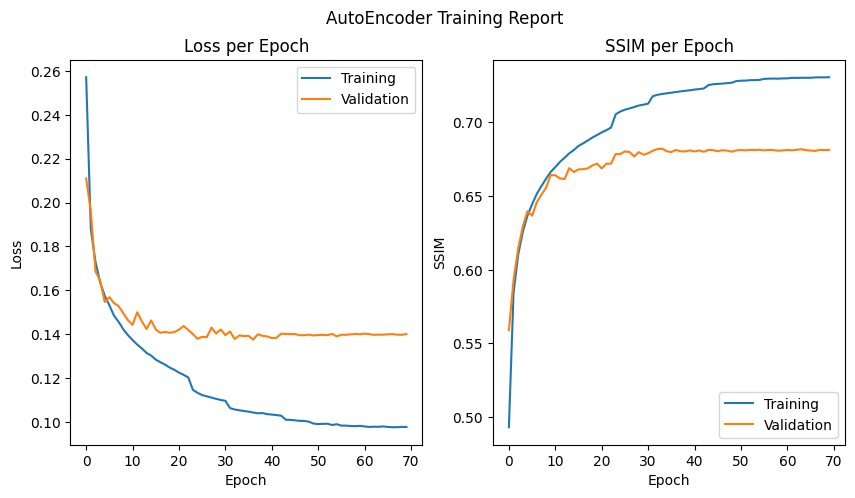

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Use this cell to:
# 1. Train the AutoEncoder model while bookkeeping the training and validation losses and SSIM scores for each epoch
# 2. Save the model weights using AutoEncoder.save_model_weights method
# 3. Save the training report using AutoEncoder.save_training_report method

# YOUR CODE HERE
# raise NotImplementedError()
def ssim_loss(img1, img2):
    img1_np = img1.squeeze().detach().cpu().numpy()
    img2_np = img2.squeeze().detach().cpu().numpy()

    return 1 - ssim(img1_np, img2_np, data_range=img2_np.max() - img2_np.min())

def hybrid_loss(recon_x, x):
    mse_loss = torch.nn.functional.mse_loss(recon_x, x)
    ssim_l = torch.tensor(ssim_loss(recon_x, x), device=recon_x.device)
    return mse_loss + ssim_l

def train(
    model: AutoEncoder,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader,
    num_epochs: int,
    lr: float
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = hybrid_loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses, val_losses = [], []
    train_ssim_scores, val_ssim_scores = [], []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss, total_train_ssim = 0.0, 0.0
        total_train = 0

        for aug_img, clean_img, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
            aug_img, clean_img = aug_img.to(device), clean_img.to(device)

            optimizer.zero_grad()
            reconstructed_img = model(aug_img)

            loss = criterion(reconstructed_img, clean_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_train_loss += loss.item() * clean_img.size(0)

            reconstructed_np = reconstructed_img.squeeze(1).cpu().detach().numpy()
            clean_np = clean_img.squeeze(1).cpu().detach().numpy()
            total_train_ssim += get_ssim(reconstructed_np, clean_np) * clean_img.size(0)
            total_train += labels.size(0)

        avg_train_loss = total_train_loss / total_train
        avg_train_ssim = total_train_ssim / total_train
        train_losses.append(avg_train_loss)
        train_ssim_scores.append(avg_train_ssim)

        model.eval()
        total_val_loss, total_val_ssim = 0.0, 0.0
        total_val = 0

        with torch.no_grad():
            for aug_img, clean_img, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
                aug_img, clean_img = aug_img.to(device), clean_img.to(device)
                reconstructed_img = model(aug_img)

                loss = criterion(reconstructed_img, clean_img)
                total_val_loss += loss.item() * clean_img.size(0)

                reconstructed_np = [img for img in reconstructed_img.squeeze(1).cpu().numpy()]
                clean_np = [img for img in clean_img.squeeze(1).cpu().numpy()]
                total_val_ssim += get_ssim(reconstructed_np, clean_np) * clean_img.size(0)
                total_val += labels.size(0)

        avg_val_loss = total_val_loss / total_val
        avg_val_ssim = total_val_ssim / total_val
        val_losses.append(avg_val_loss)
        val_ssim_scores.append(avg_val_ssim)

        scheduler.step(avg_val_loss)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.4f}, Train SSIM: {avg_train_ssim:.4f} "
            f"Val Loss: {avg_val_loss:.4f}, Val SSIM: {avg_val_ssim:.4f}"
        )

    model.save_model_weights()
    # files.download("auto_encoder.pth")
    model.save_training_report(train_losses, val_losses, train_ssim_scores, val_ssim_scores)
    # files.download("auto_encoder.png")


batch_size : int
latent_dim : int
num_epochs : int
learning_rate : float

batch_size = 64
latent_dim = 100
num_epochs = 32
learning_rate = 0.001

path_to_train_images_aug_dir = str(PATH_TO_TRAIN_DATA_DIR + "/aug")
path_to_train_images_clean_dir = str(PATH_TO_TRAIN_DATA_DIR + "/clean")
train_fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_train_images_aug_dir,
    path_to_clean_images_dir=path_to_train_images_clean_dir,
)

train_fashion_mnist_dataloader = torch.utils.data.DataLoader(
    dataset=train_fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

path_to_test_images_aug_dir = str(PATH_TO_TEST_DATA_DIR + "/aug")
path_to_test_images_clean_dir = str(PATH_TO_TEST_DATA_DIR + "/clean")
test_fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_test_images_aug_dir,
    path_to_clean_images_dir=path_to_test_images_clean_dir,
)

test_fashion_mnist_dataloader = torch.utils.data.DataLoader(
    dataset=test_fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=False
)

autoencoder = AutoEncoder(latent_dim)

train(
    autoencoder,
    train_fashion_mnist_dataloader,
    test_fashion_mnist_dataloader,
    num_epochs=num_epochs,
    lr=learning_rate
)

In [ ]:
# tests for q3b

# `q4`: Variational AutoEncoder Model
* `q4a`: `VariationalAutoEncoder` class: Implement a VariationalAutoEncoder that uses the Encoder and Decoder Modules implemented in `q2a` and `q2b`. Constraints:
  1. The number of parameters in the VariationalAutoEncoder must be between 4,000 and 2,000,000 (both inclusive).
  2. The input tensor will be of shape `[batch_size, 1, 28, 28]` that comes out of the DataLoader of the `FashionMNIST` dataset.
  3. The output tensor must be of shape `[batch_size, 1, 28, 28]`. This tensor will be the reconstructed image of the input tensor.

* `q4b`: Training the models: Implement the training loop for the VariationalAutoEncoder model. Constraints:
  1. Use the `FashionMNIST` dataset implemented in `q1` to load the data.
  2. Use the `VariationalAutoEncoder` model implemented in `q4a`.
  3. You are free to choose any loss function, optimizer, and hyperparameters.
  4. **You must**:
     1. Book-keep the training and validation losses and SSIM scores for each epoch and use it to plot the training curves with the `VariationalAutoEncoder.save_training_report` method.
     2. To calculate the SSIM score, you can use the `get_ssim` function provided below.
     3. Save the model weights using `VariationalAutoEncoder.save_model_weights` method.


`q4` Grading [Total: 1.5 points]:
1. `q4a`: `VariationalAutoEncoder` class: `0.5` points if the code runs without any errors on hidden test cases, otherwise 0 points. No partial points for this question.
2. `q4b`: Training the models: `1` points. You will be awarded points based on the SSIM score of the `VariationalAutoEncoder` model on a **hidden test set**. The grading will be as follows:
   1. 0.8 or more: `1` point
   2. 0.7 or more: `0.8` points
   3. 0.6 or more: `0.6` points
   4. 0.5 or more: `0.4` points
   5. 0.4 or more: `0.2` points
   6. Less than 0.4: `0` points

You are provided with the following template. **Populate only the sections marked as `# YOUR CODE HERE`. Do not modify other parts of the template.**

## `q4a`: `VariationalAutoEncoder` class

In [15]:
class VariationalAutoEncoder(torch.nn.Module):
    def __init__(self, latent_dim: int):
        super(VariationalAutoEncoder, self).__init__()
        self.encoder = Encoder(output_channels=latent_dim * 2, type_of_autoencoder="vae")
        self.decoder = Decoder(input_channels=latent_dim, type_of_autoencoder="vae")
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        # YOUR CODE HERE
        # raise NotImplementedError()
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, input_tensor):
        # YOUR CODE HERE
        # raise NotImplementedError()
        encoded = self.encoder(input_tensor)
        mu, log_var = torch.chunk(encoded, 2, dim=1)
        z = self.reparameterize(mu, log_var)
        reconstructed = self.decoder(z)
        return reconstructed, mu, log_var

    def loss_function(self, predicted_images, gt_images, mu, log_var):
        # YOUR CODE HERE
        # raise NotImplementedError()
        mse_loss = torch.nn.functional.mse_loss(predicted_images, gt_images)

        ssim_loss = 1 - torch.mean((2 * gt_images * predicted_images + 0.01) /
                                    (gt_images ** 2 + predicted_images ** 2 + 0.01))

        perceptual_loss = torch.nn.functional.l1_loss(predicted_images, gt_images)

        loss = 0.4 * mse_loss + 0.3 * perceptual_loss + 0.2 * ssim_loss
        return loss

    def save_model_weights(self):
        torch.save(self.state_dict(), "variational_auto_encoder.pth")

    def load_model_weights(self):
        self.load_state_dict(torch.load("variational_auto_encoder.pth"))

    def save_training_report(
        self,
        list_of_train_losses: List[float],
        list_of_val_losses: List[float],
        list_of_train_ssim_scores: List[float],
        list_of_val_ssim_scores: List[float],
    ):
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title("Loss per Epoch")
        plt.plot(list_of_train_losses, label="Training")
        plt.plot(list_of_val_losses, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.title("SSIM per Epoch")
        plt.plot(list_of_train_ssim_scores, label="Training")
        plt.plot(list_of_val_ssim_scores, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("SSIM")
        plt.legend()

        plt.suptitle("VariationalAutoEncoder Training Report")

        plt.savefig("variational_auto_encoder.png")
        plt.show()

In [ ]:
# tests for q4a

variational_autoencoder = VariationalAutoEncoder(latent_dim=64)

random_input_tensor = torch.randn(1, 1, 28, 28)
output = variational_autoencoder(random_input_tensor)


del variational_autoencoder

## `q4b`: Training the model

Epoch 1/8 [Validation]: 100%|██████████| 79/79 [00:02<00:00, 34.01it/s]


Epoch [1/8] - Train Loss: 0.0762, Train SSIM: 0.4926, Val Loss: 0.0622, Val SSIM: 0.5496


Epoch 2/8 [Validation]: 100%|██████████| 79/79 [00:03<00:00, 25.51it/s]


Epoch [2/8] - Train Loss: 0.0571, Train SSIM: 0.5796, Val Loss: 0.0539, Val SSIM: 0.5979


Epoch 3/8 [Validation]: 100%|██████████| 79/79 [00:03<00:00, 24.42it/s]


...

Epoch [6/8] - Train Loss: 0.0482, Train SSIM: 0.6395, Val Loss: 0.0481, Val SSIM: 0.6399


Epoch 7/8 [Validation]: 100%|██████████| 79/79 [00:02<00:00, 33.91it/s]


Epoch [7/8] - Train Loss: 0.0472, Train SSIM: 0.6461, Val Loss: 0.0474, Val SSIM: 0.6460


Epoch 8/8 [Validation]: 100%|██████████| 79/79 [00:04<00:00, 19.28it/s]


Epoch [8/8] - Train Loss: 0.0462, Train SSIM: 0.6522, Val Loss: 0.0471, Val SSIM: 0.6478


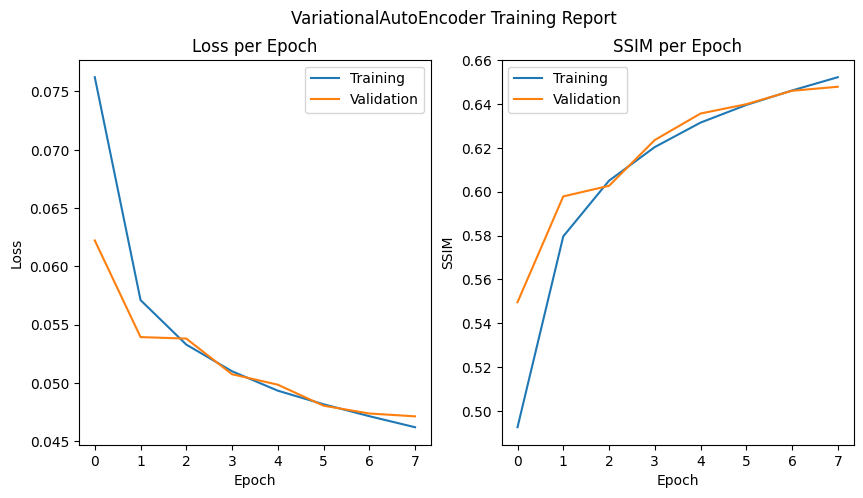

In [17]:
# Use this cell to:
# 1. Train the VariationalAutoEncoder model while bookkeeping the training and validation losses and SSIM scores for each epoch
# 2. Save the model weights using VariationalAutoEncoder.save_model_weights method
# 3. Save the training report using VariationalAutoEncoder.save_training_report method


# YOUR CODE HERE
# raise NotImplementedError()
def train_vae(
    model: VariationalAutoEncoder,
    train_dataloader: torch.utils.data.DataLoader,
    val_dataloader: torch.utils.data.DataLoader,
    num_epochs: int,
    learning_rate: float
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses, val_losses = [], []
    train_ssim_scores, val_ssim_scores = [], []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss, total_train_ssim = 0.0, 0.0
        total_train = 0

        for aug_img, clean_img, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
            aug_img, clean_img = aug_img.to(device), clean_img.to(device)

            optimizer.zero_grad()
            reconstructed_img, mu, log_var = model(aug_img)

            loss = model.loss_function(reconstructed_img, clean_img, mu, log_var)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_train_loss += loss.item() * clean_img.size(0)

            reconstructed_np = [img for img in reconstructed_img.squeeze(1).cpu().detach().numpy()]
            clean_np = [img for img in clean_img.squeeze(1).cpu().detach().numpy()]
            total_train_ssim += get_ssim(reconstructed_np, clean_np) * clean_img.size(0)
            total_train += labels.size(0)


        avg_train_loss = total_train_loss / total_train
        avg_train_ssim = total_train_ssim / total_train
        train_losses.append(avg_train_loss)
        train_ssim_scores.append(avg_train_ssim)

        model.eval()
        total_val_loss, total_val_ssim = 0.0, 0.0
        total_val = 0

        with torch.no_grad():
            for aug_img, clean_img, labels in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
                aug_img, clean_img = aug_img.to(device), clean_img.to(device)

                reconstructed_img, mu, log_var = model(aug_img)
                loss = model.loss_function(reconstructed_img, clean_img, mu, log_var)

                total_val_loss += loss.item() * clean_img.size(0)

                reconstructed_np = [img for img in reconstructed_img.squeeze(1).cpu().detach().numpy()]
                clean_np = [img for img in clean_img.squeeze(1).cpu().detach().numpy()]
                total_val_ssim += get_ssim(reconstructed_np, clean_np) * clean_img.size(0)
                total_val += labels.size(0)

        avg_val_loss = total_val_loss / total_val
        avg_val_ssim = total_val_ssim / total_val
        val_losses.append(avg_val_loss)
        val_ssim_scores.append(avg_val_ssim)

        scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Train SSIM: {avg_train_ssim:.4f}, Val Loss: {avg_val_loss:.4f}, Val SSIM: {avg_val_ssim:.4f}")

    model.save_model_weights()
    # files.download("variational_auto_encoder.pth")
    model.save_training_report(train_losses, val_losses, train_ssim_scores, val_ssim_scores)
    # files.download("variational_auto_encoder.png")

batch_size : int
latent_dim : int
num_epochs : int
learning_rate : float

batch_size = 64
latent_dim = 100
num_epochs = 32
learning_rate = 0.001

path_to_train_images_aug_dir = str(PATH_TO_TRAIN_DATA_DIR + "/aug")
path_to_train_images_clean_dir = str(PATH_TO_TRAIN_DATA_DIR + "/clean")
train_fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_train_images_aug_dir,
    path_to_clean_images_dir=path_to_train_images_clean_dir,
)

train_fashion_mnist_dataloader = torch.utils.data.DataLoader(
    dataset=train_fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

path_to_test_images_aug_dir = str(PATH_TO_TEST_DATA_DIR + "/aug")
path_to_test_images_clean_dir = str(PATH_TO_TEST_DATA_DIR + "/clean")
test_fashion_mnist_dataset = FashionMNISTDataset(
    path_to_augmented_images_dir=path_to_test_images_aug_dir,
    path_to_clean_images_dir=path_to_test_images_clean_dir,
)

test_fashion_mnist_dataloader = torch.utils.data.DataLoader(
    dataset=test_fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=False
)

vautoencoder = VariationalAutoEncoder(latent_dim)

train_vae(
    vautoencoder,
    train_fashion_mnist_dataloader,
    test_fashion_mnist_dataloader,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)

In [ ]:
# tests for q4b

# `q5`: [BONUS] Conditional Variational AutoEncoder Model
* `q5a`: `ConditionalVariationalAutoEncoder` class: Implement a ConditionalVariationalAutoEncoder that uses the Encoder and Decoder Modules implemented in `q2a` and `q2b`. Constraints:
  1. The number of parameters in the ConditionalVariationalAutoEncoder must be between 4,000 and 2,000,000 (both inclusive).
  2. The input tensor will be of shape `[batch_size, 1, 28, 28]` that comes out of the DataLoader of the `FashionMNIST` dataset.
  3. The output tensor must be of shape `[batch_size, 1, 28, 28]`. This tensor will be the reconstructed image of the input tensor.

* `q5b`: Training the models: Implement the training loop for the ConditionalVariationalAutoEncoder model. Constraints:
  1. Use the `FashionMNIST` dataset implemented in `q1` to load the data.
  2. Use the `ConditionalVariationalAutoEncoder` model implemented in `q5a`.
  3. You are free to choose any loss function, optimizer, and hyperparameters.
  4. **You must**:
     1. Book-keep the training and validation losses and SSIM scores for each epoch and use it to plot the training curves with the `ConditionalVariationalAutoEncoder.save_training_report` method.
     2. To calculate the SSIM score, you can use the `get_ssim` function provided below.
     3. Save the model weights using `ConditionalVariationalAutoEncoder.save_model_weights` method.


`q5` Grading [Total: 1 point]:
1. `q5b`: Training the models: `1` point. You will be awarded points based on the SSIM score of the `ConditionalVariationalAutoEncoder` model on a **hidden test set**. The grading will be as follows:
   1. 0.8 or more: `1` point
   2. 0.7 to 0.79: `0.5` points
   3. less than 0.7: `0` points

You are provided with the following template. **Populate only the sections marked as `# YOUR CODE HERE`. Do not modify other parts of the template.**

## `q5a`: [BONUS]`ConditionalVariationalAutoEncoder`

In [ ]:
class ConditionalVariationalAutoEncoder(torch.nn.Module):
    def __init__(self, latent_dim: int, condition_dim: int):
        super(ConditionalVariationalAutoEncoder, self).__init__()
        # YOUR CODE HERE
        raise NotImplementedError()

    def reparameterize(self, mu, log_var):
        # YOUR CODE HERE
        raise NotImplementedError()

    def forward(self, input_tensor, condition_tensor):
        # YOUR CODE HERE
        raise NotImplementedError()

    def loss_function(self, predicted_images, gt_images, mu, log_var):
        # YOUR CODE HERE
        raise NotImplementedError()

    def save_model_weights(self):
        torch.save(self.state_dict(), "conditional_variational_auto_encoder.pth")

    def load_model_weights(self):
        self.load_state_dict(torch.load("conditional_variational_auto_encoder.pth"))

    def save_training_report(
        self,
        list_of_train_losses: List[float],
        list_of_val_losses: List[float],
        list_of_train_ssim_scores: List[float],
        list_of_val_ssim_scores: List[float],
    ):
        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.title("Loss per Epoch")
        plt.plot(list_of_train_losses, label="Training")
        plt.plot(list_of_val_losses, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.title("SSIM per Epoch")
        plt.plot(list_of_train_ssim_scores, label="Training")
        plt.plot(list_of_val_ssim_scores, label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel("SSIM")
        plt.legend()

        plt.suptitle("ConditionalVariationalAutoEncoder Training Report")

        plt.savefig("conditional_variational_auto_encoder.png")
        plt.show()

In [ ]:
# tests for q5a

conditional_variational_autoencoder = ConditionalVariationalAutoEncoder(
    latent_dim=64, condition_dim=10
)

random_input_tensor = torch.randn(1, 1, 28, 28)
random_condition_tensor = torch.randn(1, 10)
output = conditional_variational_autoencoder(
    random_input_tensor, random_condition_tensor
)


del conditional_variational_autoencoder

## `q5b`: [BONUS] Training the model

In [ ]:
# Use this cell to:
# 1. Train the ConditionalVariationalAutoEncoder model while bookkeeping the training and validation losses and SSIM scores for each epoch
# 2. Save the model weights using ConditionalVariationalAutoEncoder.save_model_weights method
# 3. Save the training report using ConditionalVariationalAutoEncoder.save_training_report method


# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
# tests for q5b

In [ ]:
# tests for q3b, q4b, q5b

